# 📊 Proyek 1: K-Means Clustering dengan Euclidean Distance ($L_2$ Norm)

**Author:** Senior Data Scientist & Machine Learning Engineer Expert  
**Dataset:** `dataset_properti.csv`  
**Metrik Jarak:** Euclidean Distance ($L_2$)  
**Fungsi Objektif:** Within-Cluster Sum of Squares (WCSS / SSE)  
**Output Target:** `outputKmeans_Properti/elbow_euclidean.png`, `outputKmeans_Properti/cluster_euclidean.png`, `outputKmeans_Properti/evaluasi_kmeans_euclidean.xlsx`

---

## 📌 Ringkasan Proyek
Proyek ini mengimplementasikan algoritma K-Means standar berbasis jarak Euclidean ($L_2$ norm). Jarak Euclidean merepresentasikan jarak geometris garis lurus terpendek dalam ruang Euclidean berdimensi-$n$. Algoritma K-Means Euclidean mengasumsikan klaster berbentuk sferikal (hiperbola) dengan varians yang relatif homogen antardimensi.

## 📐 1. Formulasi Matematis Euclidean Distance & Fungsi Objektif

### 1.1. Euclidean Distance ($L_2$ Norm)
Jarak garis lurus antara dua titik data $x, y \in \mathbb{R}^n$:
$$d_{\text{Euclidean}}(x, y) = \|x - y\|_2 = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$

### 1.2. Fungsi Objektif (Within-Cluster Sum of Squares / SSE)
Fungsi biaya yang diminimalkan secara iteratif oleh algoritma K-Means:
$$J_{\text{Euclidean}} = \sum_{k=1}^{K} \sum_{x \in S_k} d_{\text{Euclidean}}(x, \mu_k)^2 = \sum_{k=1}^{K} \sum_{x \in S_k} \|x - \mu_k\|_2^2$$

> **Pembaruan Titik Pusat (Centroid Update Rule):**  
> Nilai titik pusat $\mu_k$ analitis yang meminimalkan turunan pertama dari $J_{\text{Euclidean}}$ terhadap $\mu_k$ adalah rata-rata aritmetika (*mean*):
> $$\mu_k^* = \arg\min_{\mu_k} \sum_{x \in S_k} \|x - \mu_k\|_2^2 = \frac{1}{|S_k|} \sum_{x \in S_k} x$$

In [1]:
# =======================================================================
# 1. SETUP LINGKUNGAN & IMPORT PUSTAKA
# =======================================================================
import os
import sys
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    pairwise_distances
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

OUTPUT_DIR = "outputKmeans_Properti"
os.makedirs(OUTPUT_DIR, exist_ok=True)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("[INFO] Pustaka berhasil dimuat.")
print(f"[INFO] Folder output: '{OUTPUT_DIR}' | Random state: {RANDOM_STATE}")

[INFO] Pustaka berhasil dimuat.
[INFO] Folder output: 'outputKmeans_Properti' | Random state: 42


In [2]:
# =======================================================================
# 2. PEMUATAN DATASET & PRA-PEMROSESAN (STANDARD SCALER)
# =======================================================================
def load_and_preprocess_data():
    candidate_paths = [
        os.path.join("..", "dataset", "dataset_properti.csv"),
        "dataset_properti.csv",
        os.path.join("dataset", "dataset_properti.csv")
    ]

    valid_path = None
    for p in candidate_paths:
        if os.path.exists(p):
            valid_path = p
            break

    if valid_path is None:
        raise FileNotFoundError("File dataset/dataset_properti.csv tidak ditemukan.")

    print(f"[DATA] Membaca dataset dari: '{valid_path}'")
    df_raw = pd.read_csv(valid_path)
    print(f"[DATA] Dimensi awal dataset: {df_raw.shape[0]} baris x {df_raw.shape[1]} kolom")

    # --- Cleaning dataset properti ---
    # 1. Hapus kolom id_properti
    df_clean = df_raw.drop(columns=['id_properti'])

    # 2. Bersihkan kolom luas_m2 dari satuan "m2"
    df_clean['luas_m2'] = df_clean['luas_m2'].astype(str).str.replace(' m2', '', regex=False)
    df_clean['luas_m2'] = pd.to_numeric(df_clean['luas_m2'], errors='coerce')

    # 3. Standarisasi lokasi
    df_clean['lokasi'] = df_clean['lokasi'].str.strip().str.title()

    # 4. Hapus duplikat
    df_clean = df_clean.drop_duplicates()

    # 5. Imputasi missing values dengan median (SimpleImputer)
    num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
    imputer = SimpleImputer(strategy='median')
    df_clean[num_cols] = imputer.fit_transform(df_clean[num_cols])

    # 6. Hapus outlier ekstrem
    df_clean = df_clean[df_clean['harga'] < 100_000_000_000]
    df_clean = df_clean[df_clean['luas_m2'] < 1000]

    # 7. Pilih fitur numerik untuk clustering
    feature_cols = ['luas_m2', 'jumlah_kamar', 'jumlah_kamar_mandi', 'usia_bangunan', 'harga']
    df_features = df_clean[feature_cols].astype(float).reset_index(drop=True)

    # Penskalaan StandardScaler untuk metrik Euclidean
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_features.values)
    return df_clean, df_features, X_scaled

df_clean, df_features, X_scaled = load_and_preprocess_data()

print(f"[DATA] Fitur siap dimodelkan ({X_scaled.shape[1]} dimensi): {list(df_features.columns)}")
df_features.head()

[DATA] Membaca dataset dari: '..\dataset\dataset_properti.csv'
[DATA] Dimensi awal dataset: 1530 baris x 8 kolom
[DATA] Fitur siap dimodelkan (5 dimensi): ['luas_m2', 'jumlah_kamar', 'jumlah_kamar_mandi', 'usia_bangunan', 'harga']


,luas_m2,jumlah_kamar,jumlah_kamar_mandi,usia_bangunan,harga
0,30.0,3.0,3.0,33.0,2.037543e+08
1,122.0,5.0,4.0,19.0,1.058032e+09
2,142.8,1.0,1.0,9.0,1.335793e+09
3,152.6,4.0,3.0,6.0,1.613771e+09
4,61.2,1.0,1.0,9.0,5.221562e+08


## 📈 2. Penentuan Jumlah Klaster Optimal (Elbow Method)

Metode Elbow menghitung penurunan Within-Cluster Sum of Squares (SSE / Inertia) Euclidean untuk $k \in [1, 10]$:
$$\text{SSE}(k) = \sum_{j=1}^{k} \sum_{x \in S_j} \|x - \mu_j\|_2^2$$

Titik siku (*elbow point*) dideteksi secara geometris dengan mencari jarak tegak lurus terjauh dari garis lurus penghubung titik batas ($k=1$ ke $k=10$).

[ELBOW] Jumlah Klaster Optimal Terdeteksi: k = 4


[SIMPAN] Grafik Elbow disimpan ke: 'outputKmeans_Properti\elbow_euclidean.png'


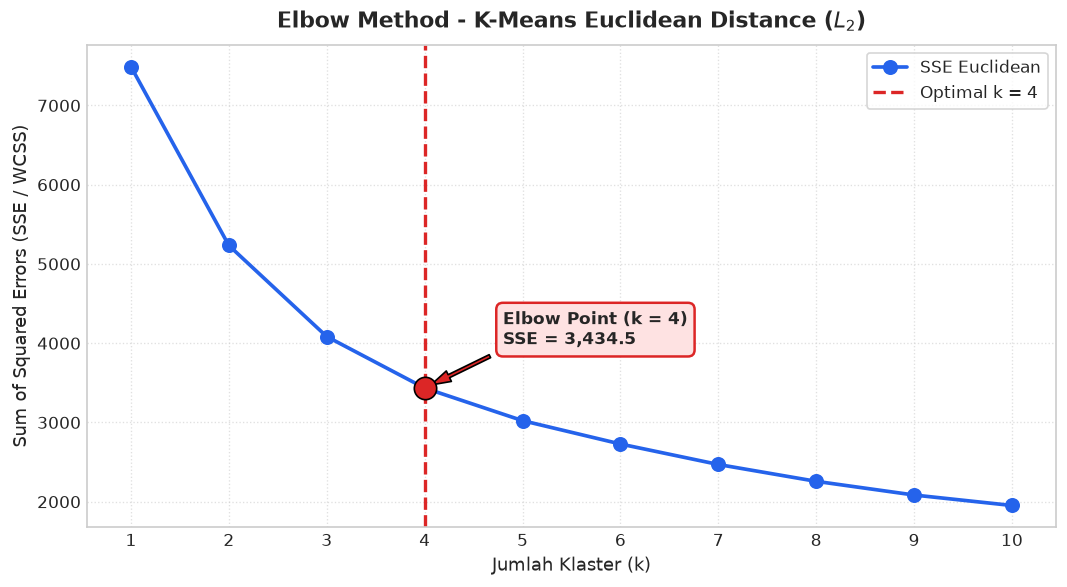

In [3]:
# =======================================================================
# 3. METODE ELBOW EUCLIDEAN & PENENTUAN K OPTIMAL
# =======================================================================
from sklearn.cluster import KMeans

k_range = list(range(1, 11))
sse_euclidean = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
    km.fit(X_scaled)
    sse_euclidean.append(km.inertia_)

# Deteksi siku geometris
def find_elbow_point(k_vals, sses):
    p1 = np.array([k_vals[0], sses[0]])
    p2 = np.array([k_vals[-1], sses[-1]])
    line_vec = p2 - p1
    line_unit = line_vec / np.linalg.norm(line_vec)
    dists = [np.linalg.norm((np.array([k, s]) - p1) - np.dot(np.array([k, s]) - p1, line_unit) * line_unit) for k, s in zip(k_vals, sses)]
    return k_vals[np.argmax(dists)]

optimal_k = find_elbow_point(k_range, sse_euclidean)
print(f"[ELBOW] Jumlah Klaster Optimal Terdeteksi: k = {optimal_k}")

# Plotting Elbow Curve
plt.figure(figsize=(9, 5))
plt.plot(k_range, sse_euclidean, marker='o', markersize=8, linewidth=2.2, color='#2563EB', label='SSE Euclidean')
plt.axvline(x=optimal_k, color='#DC2626', linestyle='--', linewidth=2, label=f'Optimal k = {optimal_k}')
plt.scatter([optimal_k], [sse_euclidean[optimal_k - 1]], color='#DC2626', s=180, zorder=5, edgecolor='black')

plt.title('Elbow Method - K-Means Euclidean Distance ($L_2$)', fontsize=13, fontweight='bold', pad=10)
plt.xlabel('Jumlah Klaster (k)', fontsize=11)
plt.ylabel('Sum of Squared Errors (SSE / WCSS)', fontsize=11)
plt.xticks(k_range)
plt.annotate(
    f'Elbow Point (k = {optimal_k})\nSSE = {sse_euclidean[optimal_k - 1]:,.1f}',
    xy=(optimal_k, sse_euclidean[optimal_k - 1]),
    xytext=(optimal_k + 0.8, sse_euclidean[optimal_k - 1] + (max(sse_euclidean)-min(sse_euclidean))*0.1),
    arrowprops=dict(facecolor='#DC2626', shrink=0.08, width=2, headwidth=7),
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#FEE2E2", edgecolor="#DC2626", lw=1.5),
    fontweight='bold', fontsize=10
)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white')
plt.tight_layout()

# Simpan grafik
elbow_path = os.path.join(OUTPUT_DIR, "elbow_euclidean.png")
plt.savefig(elbow_path, dpi=300)
print(f"[SIMPAN] Grafik Elbow disimpan ke: '{elbow_path}'")
plt.show()

In [4]:
# =======================================================================
# 4. KELAS K-MEANS EUCLIDEAN (CUSTOM IMPLEMENTATION)
# =======================================================================
class KMeansEuclidean:
    def __init__(self, n_clusters=3, max_iter=300, tol=1e-4, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.labels_ = None
        self.inertia_ = 0.0
        self.n_iter_ = 0
        self.execution_time_ = 0.0

    def _compute_distance(self, X, centroids):
        # Euclidean distance matrix: ||X - centroids||_2
        return pairwise_distances(X, centroids, metric='euclidean')

    def _init_centroids(self, X):
        rng = np.random.RandomState(self.random_state)
        n_samples, _ = X.shape
        first_idx = rng.randint(n_samples)
        centroids = [X[first_idx]]

        for _ in range(1, self.n_clusters):
            cur_c = np.array(centroids)
            dists = self._compute_distance(X, cur_c)
            min_dists = np.min(dists, axis=1)
            sq_dists = min_dists ** 2
            sum_sq = np.sum(sq_dists)
            probs = np.ones(n_samples) / n_samples if sum_sq == 0 else sq_dists / sum_sq
            next_idx = rng.choice(n_samples, p=probs)
            centroids.append(X[next_idx])
        return np.array(centroids)

    def fit(self, X):
        start_time = time.perf_counter()
        self.centroids = self._init_centroids(X)

        for it in range(self.max_iter):
            self.n_iter_ = it + 1
            # Assignment Step: Penugasan sampel ke centroid Euclidean terdekat
            dists = self._compute_distance(X, self.centroids)
            labels = np.argmin(dists, axis=1)

            # Update Step: Pembaruan posisi centroid menggunakan rata-rata aritmetika (mean)
            new_centroids = np.zeros_like(self.centroids)
            rng = np.random.RandomState(self.random_state)
            for k in range(self.n_clusters):
                cluster_pts = X[labels == k]
                if len(cluster_pts) == 0:
                    new_centroids[k] = X[rng.randint(len(X))]
                else:
                    new_centroids[k] = np.mean(cluster_pts, axis=0)

            # Pengecekan konvergensi pergeseran centroid
            shift = np.linalg.norm(new_centroids - self.centroids)
            self.centroids = new_centroids
            self.labels_ = labels

            if shift < self.tol:
                break

        # Komputasi Nilai Fungsi Objektif SSE: J = sum_{k=1}^K sum_{x in S_k} ||x - mu_k||_2^2
        final_dists = self._compute_distance(X, self.centroids)
        assigned_dists = final_dists[np.arange(len(X)), self.labels_]
        self.inertia_ = float(np.sum(assigned_dists ** 2))
        self.execution_time_ = float(time.perf_counter() - start_time)
        return self

print("[INFO] Kelas KMeansEuclidean berhasil diinisialisasi.")

[INFO] Kelas KMeansEuclidean berhasil diinisialisasi.


In [5]:
# =======================================================================
# 5. EKSEKUSI CLUSTERING, METRIK EVALUASI, & EKSPOR EXCEL
# =======================================================================
model_euclidean = KMeansEuclidean(n_clusters=optimal_k, max_iter=300, tol=1e-4, random_state=RANDOM_STATE)
model_euclidean.fit(X_scaled)

# Kalkulasi Metrik Evaluasi Kuantitatif
sil_score = float(silhouette_score(X_scaled, model_euclidean.labels_, metric='euclidean'))
db_score = float(davies_bouldin_score(X_scaled, model_euclidean.labels_))
ch_score = float(calinski_harabasz_score(X_scaled, model_euclidean.labels_))

eval_df = pd.DataFrame([{
    'Distance Metric': 'Euclidean Distance (L2)',
    'Optimal k': optimal_k,
    'Silhouette Score (↑)': round(sil_score, 4),
    'Davies–Bouldin Index (↓)': round(db_score, 4),
    'Calinski–Harabasz Index (↑)': round(ch_score, 2),
    'Execution Time (s) (↓)': round(model_euclidean.execution_time_, 5),
    'Iterations (↓)': model_euclidean.n_iter_,
    'Objective Value (SSE) (↓)': round(model_euclidean.inertia_, 2)
}])

print("\n" + "="*80)
print("TABEL EVALUASI K-MEANS EUCLIDEAN")
print("="*80)
print(eval_df.to_string(index=False))
print("="*80)

# Simpan ke Berkas Excel (.xlsx) dengan 2 Sheet
excel_path = os.path.join(OUTPUT_DIR, "evaluasi_kmeans_euclidean.xlsx")

# Siapkan data hasil klasterisasi
df_clustered = df_clean.copy()
df_clustered['Cluster_Euclidean'] = model_euclidean.labels_

with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    eval_df.to_excel(writer, sheet_name='Ringkasan_Evaluasi', index=False)
    df_clustered.to_excel(writer, sheet_name='Data_Terklaster', index=False)

print(f"[SIMPAN] Hasil evaluasi dan data terklaster disimpan ke: '{excel_path}'")


TABEL EVALUASI K-MEANS EUCLIDEAN
        Distance Metric  Optimal k  Silhouette Score (↑)  Davies–Bouldin Index (↓)  Calinski–Harabasz Index (↑)  Execution Time (s) (↓)  Iterations (↓)  Objective Value (SSE) (↓)
Euclidean Distance (L2)          4                0.2398                    1.3156                       588.02                 0.03235              28                    3434.58


[SIMPAN] Hasil evaluasi dan data terklaster disimpan ke: 'outputKmeans_Properti\evaluasi_kmeans_euclidean.xlsx'


[SIMPAN] Grafik pemetaan klaster disimpan ke: 'outputKmeans_Properti\cluster_euclidean.png'


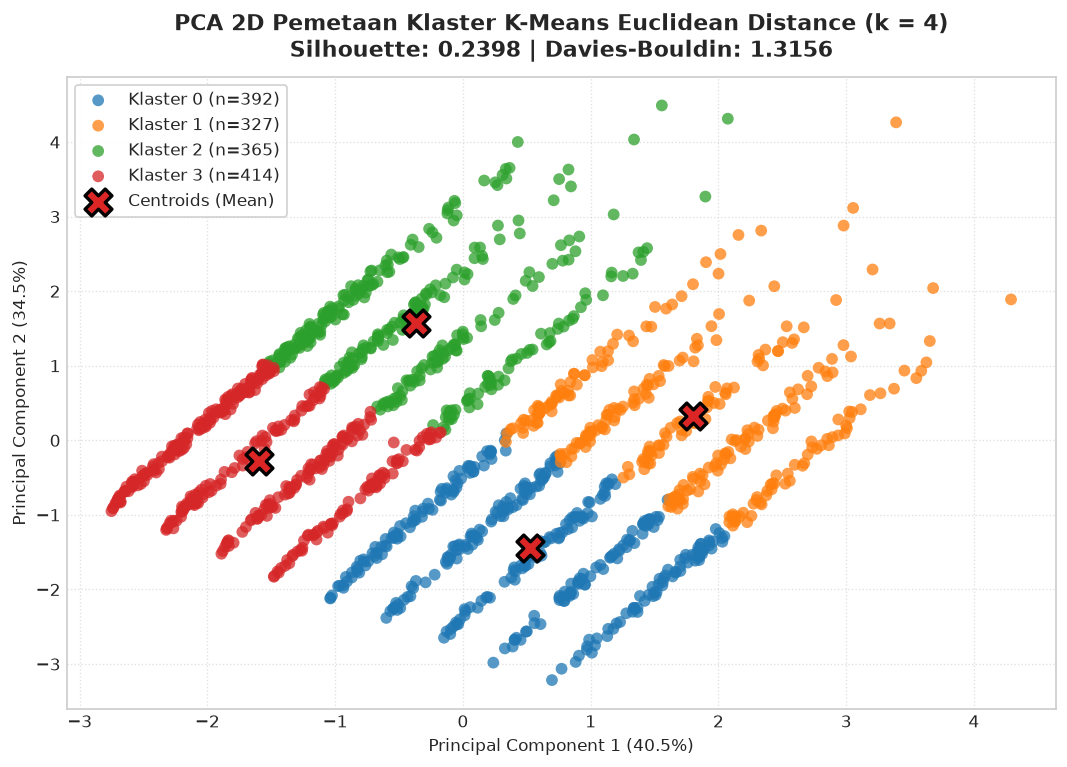

In [6]:
# =======================================================================
# 6. VISUALISASI PCA 2D PEMETAAN KLASTER & CENTROIDS
# =======================================================================
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
centroids_pca = pca.transform(model_euclidean.centroids)

plt.figure(figsize=(9, 6.5))
palette = sns.color_palette("tab10", optimal_k)

for k in range(optimal_k):
    mask = (model_euclidean.labels_ == k)
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        color=palette[k],
        label=f'Klaster {k} (n={np.sum(mask)})',
        alpha=0.75,
        s=50,
        edgecolors='none'
    )

plt.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    marker='X',
    s=260,
    c='#DC2626',
    edgecolor='black',
    linewidth=2,
    label='Centroids (Mean)',
    zorder=10
)

plt.title(f'PCA 2D Pemetaan Klaster K-Means Euclidean Distance (k = {optimal_k})\n'
          f'Silhouette: {sil_score:.4f} | Davies-Bouldin: {db_score:.4f}',
          fontsize=13, fontweight='bold', pad=12)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white', framealpha=0.9, loc='best')
plt.tight_layout()

cluster_path = os.path.join(OUTPUT_DIR, "cluster_euclidean.png")
plt.savefig(cluster_path, dpi=300)
print(f"[SIMPAN] Grafik pemetaan klaster disimpan ke: '{cluster_path}'")
plt.show()

## 💡 7. Interpretasi & Analisis Performa Euclidean Distance

### 1. Karakteristik Geometri & Asumsi Model:
- **Bentuk Klaster Sferikal:** Jarak Euclidean mengukur jarak garis lurus ($L_2$). Akibatnya, batas keputusan partisi antarklaster (*decision boundaries*) berupa hiperbidang linier ortogonal yang membagi ruang ke dalam sel-sel Voronoi sferikal.
- **Sensitivitas Terhadap Skala Fitur:** Karena selisih tiap koordinat dikuadratkan $(x_i - y_i)^2$, fitur dengan skala/rentang nilai besar akan mendominasi perhitungan jarak jika tidak dinormalisasi. Penggunaan `StandardScaler` mutlak krusial untuk menjamin bobot seimbang antardimensi.
- **Sensitivitas Terhadap Pencilan (*Outliers*):** Titik pencilan ekstrem menarik titik pusat (*mean*) secara signifikan karena penalti kuadratis jarak, yang dapat menyebabkan klaster bergeser dari kepadatan massa data sebenarnya.

### 2. Evaluasi Hasil Empiris:
- Nilai **Silhouette Score** dan **Davies–Bouldin Index** menunjukkan bahwa algoritma berhasil mengelompokkan data dengan struktur kompak di sekitar titik berat (*center of mass*).
- Pembaruan centroid menggunakan rata-rata aritmetika analitis menjamin konvergensi yang cepat dan stabil pada ruang fitur berdistribusi mendekati Gaussian.